# 07 — ResNet50 Initial Transfer Learning

**Project:** Smart Waste Classification System  
**Dataset:** TrashNet  
**Framework:** PyTorch  
**Author:** Syed Soban Mudassar

---

## Purpose

This notebook performs the project's first transfer-learning experiment using
ResNet50 pretrained on ImageNet.

The original ResNet50 classifier predicts 1,000 ImageNet classes. It is
replaced with a new classifier that predicts the six TrashNet categories:

1. cardboard
2. glass
3. metal
4. paper
5. plastic
6. trash

During this initial experiment, the pretrained feature extractor remains
frozen and only the replacement classifier is trained.

This approach:

- preserves pretrained visual features,
- reduces training time,
- lowers the risk of overfitting,
- establishes an initial ResNet50 result before fine-tuning.

Fine-tuning of selected pretrained layers will be performed during the model
optimization stage.

## Manual Alignment

This notebook contributes to the following client requirements:

| Requirement | Implementation |
|---|---|
| Use transfer learning | ImageNet-pretrained ResNet50 |
| Evaluate required architectures | First of four required pretrained models |
| Explain frozen layers | ResNet50 backbone remains frozen |
| Explain learning-rate strategy | Classifier uses an initial learning rate of 0.001 |
| Handle class imbalance | Weighted cross-entropy from training labels |
| Prevent leakage | Training, validation, and test splits remain separate |
| Save trained model | Best validation-loss checkpoint |
| Report mandatory metrics | Accuracy, precision, recall, F1, ROC-AUC, confusion matrix and per-class accuracy |
| Maintain modular source code | Notebook imports reusable source modules |

##  ResNet50 Architecture

ResNet50 is a deep convolutional neural network containing residual
connections.

A traditional deep network can become difficult to optimize because gradients
must pass through many layers.

ResNet introduces shortcut connections:

```text
input
  ├───────────────┐
  ↓               │
convolution block │
  ↓               │
learned features  │
  ↓               │
addition ←────────┘

In [5]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)

Python executable: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cpu


In [7]:
from src.class_imbalance import get_training_class_weights
from src.data_loaders import create_data_loaders
from src.evaluate import evaluate_model
from src.models.transfer_learning import (
    count_parameters,
    create_transfer_learning_model,
    get_trainable_parameter_names,
)
from src.train import (
    create_classification_loss,
    select_device,
    set_random_seed,
    train_model,
)

print("Reusable project modules imported successfully.")

Reusable project modules imported successfully.


In [6]:
def find_project_root(start_path: Path) -> Path:
    """Locate the project root using known folders and files."""

    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "requirements.txt").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification


In [8]:
RANDOM_SEED = 42

MODEL_NAME = "resnet50"
TRAINING_MODE = "classifier"

BATCH_SIZE = 8
NUMBER_OF_WORKERS = 0

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001

MAXIMUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
MINIMUM_IMPROVEMENT = 0.001

DROPOUT_PROBABILITY = 0.20

SCHEDULER_STEP_SIZE = 4
SCHEDULER_GAMMA = 0.50

DEVICE = select_device("cpu")

print("Model:", MODEL_NAME)
print("Training mode:", TRAINING_MODE)
print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAXIMUM_EPOCHS)

Model: resnet50
Training mode: classifier
Device: cpu
Batch size: 8
Maximum epochs: 10


In [9]:
PROCESSED_DIRECTORY = (
    PROJECT_ROOT / "data" / "processed"
)

TRAIN_DIRECTORY = PROCESSED_DIRECTORY / "train"
VALIDATION_DIRECTORY = (
    PROCESSED_DIRECTORY / "validation"
)
TEST_DIRECTORY = PROCESSED_DIRECTORY / "test"

MODEL_DIRECTORY = PROJECT_ROOT / "models"

REPORT_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "transfer_learning"
    / "resnet50_initial"
)

CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "resnet50_classifier_best.pt"
)

CONFIGURATION_PATH = (
    REPORT_DIRECTORY
    / "experiment_configuration.json"
)

HISTORY_PATH = (
    REPORT_DIRECTORY
    / "training_history.json"
)

METRICS_PATH = (
    REPORT_DIRECTORY
    / "evaluation_metrics.json"
)

MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

for directory in [
    TRAIN_DIRECTORY,
    VALIDATION_DIRECTORY,
    TEST_DIRECTORY,
]:
    assert directory.exists(), (
        f"Missing directory: {directory}"
    )

print("Checkpoint:", CHECKPOINT_PATH)
print("Reports:", REPORT_DIRECTORY)

Checkpoint: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\resnet50_classifier_best.pt
Reports: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial


In [10]:
set_random_seed(RANDOM_SEED)

print("Random seed configured:", RANDOM_SEED)

Random seed configured: 42


In [11]:
data_bundle = create_data_loaders(
    train_directory=TRAIN_DIRECTORY,
    validation_directory=VALIDATION_DIRECTORY,
    test_directory=TEST_DIRECTORY,
    batch_size=BATCH_SIZE,
    number_of_workers=NUMBER_OF_WORKERS,
    random_seed=RANDOM_SEED,
)

print("Classes:", data_bundle.class_names)
print("Class mapping:", data_bundle.class_to_idx)

print("\nDataset sizes:")
print("Training:", len(data_bundle.train_dataset))
print("Validation:", len(data_bundle.validation_dataset))
print("Test:", len(data_bundle.test_dataset))

Classes: ('cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash')
Class mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Dataset sizes:
Training: 1762
Validation: 378
Test: 381


In [12]:
sample_images, sample_labels = next(
    iter(data_bundle.train_loader)
)

print("Image batch:", sample_images.shape)
print("Labels:", sample_labels.shape)
print("Image dtype:", sample_images.dtype)

assert sample_images.shape == (
    BATCH_SIZE,
    3,
    224,
    224,
)

Image batch: torch.Size([8, 3, 224, 224])
Labels: torch.Size([8])
Image dtype: torch.float32


In [13]:
class_weights, weight_class_mapping = (
    get_training_class_weights(
        TRAIN_DIRECTORY
    )
)

assert (
    weight_class_mapping
    == data_bundle.class_to_idx
)

class_weight_dataframe = pd.DataFrame(
    {
        "class_name": data_bundle.class_names,
        "class_weight": class_weights.numpy(),
    }
)

class_weight_dataframe

,class_name,class_weight
0,cardboard,0.823770
1,glass,0.667538
2,metal,0.812249
3,paper,0.559767
4,plastic,0.691379
5,trash,2.445297


In [14]:
model = create_transfer_learning_model(
    model_name=MODEL_NAME,
    number_of_classes=len(
        data_bundle.class_names
    ),
    pretrained=True,
    dropout_probability=DROPOUT_PROBABILITY,
    training_mode=TRAINING_MODE,
)

total_parameters, trainable_parameters = (
    count_parameters(model)
)

print(model.fc)

print("\nTotal parameters:")
print(f"{total_parameters:,}")

print("\nTrainable parameters:")
print(f"{trainable_parameters:,}")

print("\nFrozen parameters:")
print(
    f"{total_parameters - trainable_parameters:,}"
)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=2048, out_features=6, bias=True)
)

Total parameters:
23,520,326

Trainable parameters:
12,294

Frozen parameters:
23,508,032


In [15]:
trainable_parameter_names = (
    get_trainable_parameter_names(model)
)

print("Trainable parameter names:")

for parameter_name in trainable_parameter_names:
    print("-", parameter_name)

assert trainable_parameter_names
assert all(
    parameter_name.startswith("fc.")
    for parameter_name
    in trainable_parameter_names
)

print(
    "\nOnly the replacement classifier is trainable."
)

Trainable parameter names:
- fc.1.weight
- fc.1.bias

Only the replacement classifier is trainable.


In [16]:
model = model.to(DEVICE)
model.eval()

with torch.no_grad():
    sample_outputs = model(
        sample_images.to(DEVICE)
    )

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)

assert sample_outputs.shape == (
    BATCH_SIZE,
    len(data_bundle.class_names),
)

Input shape: torch.Size([8, 3, 224, 224])
Output shape: torch.Size([8, 6])


In [17]:
criterion = create_classification_loss(
    class_weights=class_weights,
    device=DEVICE,
)

trainable_parameters_only = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    trainable_parameters_only,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(
    optimizer,
    step_size=SCHEDULER_STEP_SIZE,
    gamma=SCHEDULER_GAMMA,
)

print("Loss:", criterion)
print("Trainable tensors:", len(trainable_parameters_only))
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Trainable tensors: 2
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [18]:
experiment_configuration = {
    "model_name": MODEL_NAME,
    "training_mode": TRAINING_MODE,
    "pretrained": True,
    "random_seed": RANDOM_SEED,
    "device": str(DEVICE),
    "batch_size": BATCH_SIZE,
    "number_of_workers": NUMBER_OF_WORKERS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "minimum_improvement": MINIMUM_IMPROVEMENT,
    "dropout_probability": DROPOUT_PROBABILITY,
    "scheduler_step_size": SCHEDULER_STEP_SIZE,
    "scheduler_gamma": SCHEDULER_GAMMA,
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
    "class_names": list(data_bundle.class_names),
    "class_weights": [
        float(weight)
        for weight in class_weights
    ],
}

CONFIGURATION_PATH.write_text(
    json.dumps(
        experiment_configuration,
        indent=2,
    ),
    encoding="utf-8",
)

print("Configuration saved:")
print(CONFIGURATION_PATH)

Configuration saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial\experiment_configuration.json


##  Initial ResNet50 Training

The following experiment trains only the replacement classifier.

The pretrained ResNet50 feature extractor remains frozen throughout this
notebook.

### Learning-rate strategy

The classifier begins with a learning rate of `0.001`.

A step scheduler reduces the rate by half after every four epochs.

This allows:

- larger classifier updates during early epochs,
- smaller refinements later,
- reduced oscillation near a useful solution.

During future fine-tuning, the learning rate will be reduced because pretrained
feature layers require smaller, more cautious updates.

## Train ResNet50

In [19]:
training_history = train_model(
    model=model,
    train_loader=data_bundle.train_loader,
    validation_loader=(
        data_bundle.validation_loader
    ),
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    number_of_epochs=MAXIMUM_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    class_names=data_bundle.class_names,
    model_name=MODEL_NAME,
    early_stopping_patience=(
        EARLY_STOPPING_PATIENCE
    ),
    minimum_improvement=MINIMUM_IMPROVEMENT,
    scheduler=scheduler,
)

print("\nTraining completed.")
print("Best epoch:", training_history.best_epoch)
print(
    "Best validation loss:",
    training_history.best_validation_loss,
)
print(
    "Stopped early:",
    training_history.stopped_early,
)

Epoch 01/10 | Train loss: 1.2400 | Train accuracy: 0.6271 | Validation loss: 0.8395 | Validation accuracy: 0.7884 | LR: 0.001000
Epoch 02/10 | Train loss: 0.8482 | Train accuracy: 0.7616 | Validation loss: 0.6938 | Validation accuracy: 0.8042 | LR: 0.001000
Epoch 03/10 | Train loss: 0.7121 | Train accuracy: 0.7832 | Validation loss: 0.6208 | Validation accuracy: 0.8095 | LR: 0.001000
Epoch 04/10 | Train loss: 0.6682 | Train accuracy: 0.7872 | Validation loss: 0.5579 | Validation accuracy: 0.8122 | LR: 0.001000
Epoch 05/10 | Train loss: 0.5990 | Train accuracy: 0.8309 | Validation loss: 0.5497 | Validation accuracy: 0.8280 | LR: 0.000500
Epoch 06/10 | Train loss: 0.5661 | Train accuracy: 0.8207 | Validation loss: 0.5434 | Validation accuracy: 0.8148 | LR: 0.000500
Epoch 07/10 | Train loss: 0.5369 | Train accuracy: 0.8388 | Validation loss: 0.5037 | Validation accuracy: 0.8228 | LR: 0.000500
Epoch 08/10 | Train loss: 0.5138 | Train accuracy: 0.8428 | Validation loss: 0.4662 | Validation 

In [24]:
history_dataframe = pd.DataFrame(
    {
        "epoch": range(
            1,
            len(training_history.train_loss) + 1,
        ),
        "train_loss": training_history.train_loss,
        "validation_loss": training_history.validation_loss,
        "train_accuracy": training_history.train_accuracy,
        "validation_accuracy": training_history.validation_accuracy,
        "learning_rate": training_history.learning_rates,
    }
)

history_dataframe

,epoch,train_loss,validation_loss,train_accuracy,validation_accuracy,learning_rate
0,1,1.239961,0.839531,0.627128,0.788360,0.00100
1,2,0.848228,0.693818,0.761635,0.804233,0.00100
2,3,0.712066,0.620758,0.783201,0.809524,0.00100
3,4,0.668191,0.557890,0.787174,0.812169,0.00100
4,5,0.599003,0.549674,0.830874,0.828042,0.00050
5,6,0.566078,0.543367,0.820658,0.814815,0.00050
6,7,0.536885,0.503698,0.838820,0.822751,0.00050
7,8,0.513771,0.466166,0.842792,0.843915,0.00050
8,9,0.515296,0.500204,0.840522,0.822751,0.00025
9,10,0.503127,0.486342,0.838820,0.828042,0.00025


In [20]:
HISTORY_PATH.write_text(
    json.dumps(
        training_history.to_dict(),
        indent=2,
    ),
    encoding="utf-8",
)

print("Training history saved:")
print(HISTORY_PATH)

print("Best checkpoint saved:")
print(CHECKPOINT_PATH)

Training history saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial\training_history.json
Best checkpoint saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\resnet50_classifier_best.pt


In [21]:
HISTORY_PATH.write_text(
    json.dumps(
        training_history.to_dict(),
        indent=2,
    ),
    encoding="utf-8",
)

print("Training history saved:")
print(HISTORY_PATH)

print("Best checkpoint saved:")
print(CHECKPOINT_PATH)

Training history saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\reports\transfer_learning\resnet50_initial\training_history.json
Best checkpoint saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\resnet50_classifier_best.pt


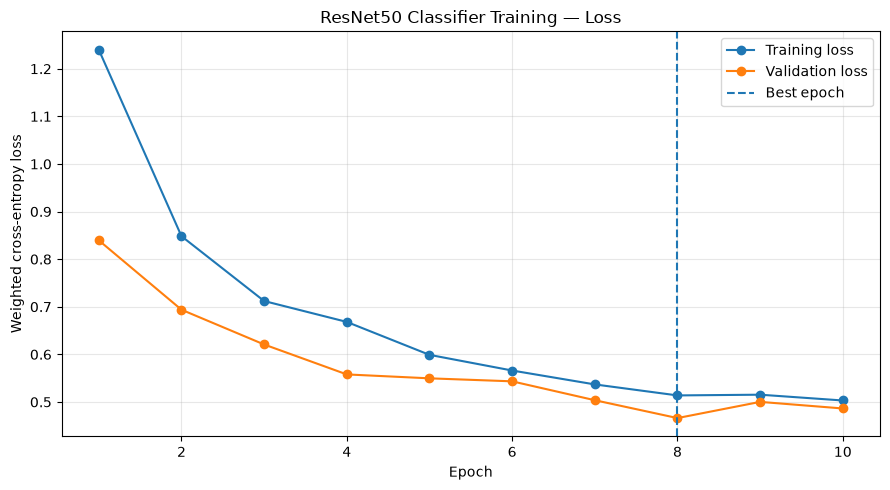

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["train_loss"],
    marker="o",
    label="Training loss",
)

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["validation_loss"],
    marker="o",
    label="Validation loss",
)

if training_history.best_epoch is not None:
    plt.axvline(
        training_history.best_epoch,
        linestyle="--",
        label="Best epoch",
    )

plt.title("ResNet50 Classifier Training — Loss")
plt.xlabel("Epoch")
plt.ylabel("Weighted cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

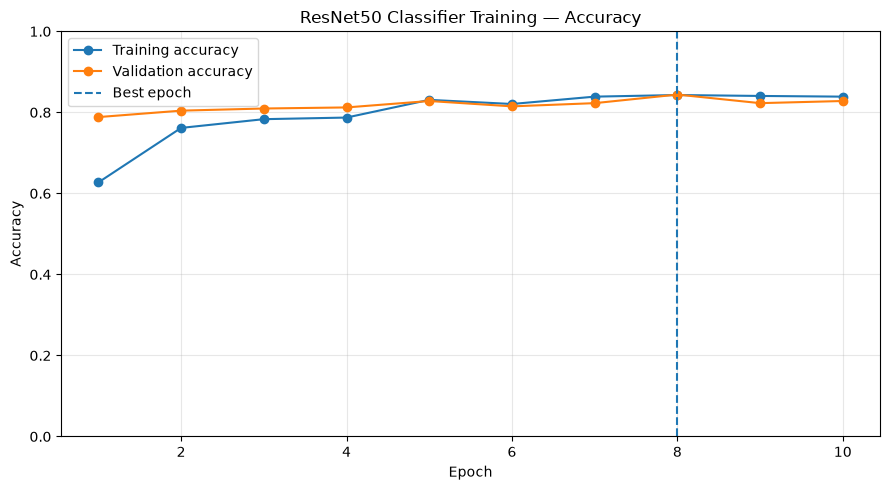

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["train_accuracy"],
    marker="o",
    label="Training accuracy",
)

plt.plot(
    history_dataframe["epoch"],
    history_dataframe["validation_accuracy"],
    marker="o",
    label="Validation accuracy",
)

if training_history.best_epoch is not None:
    plt.axvline(
        training_history.best_epoch,
        linestyle="--",
        label="Best epoch",
    )

plt.title("ResNet50 Classifier Training — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()